<ipython-input-2-3332d975280c>:24: RuntimeWarning: divide by zero encountered in log
  return (c * np.log(1 + image)).astype(np.uint8)
<ipython-input-2-3332d975280c>:24: RuntimeWarning: invalid value encountered in cast
  return (c * np.log(1 + image)).astype(np.uint8)


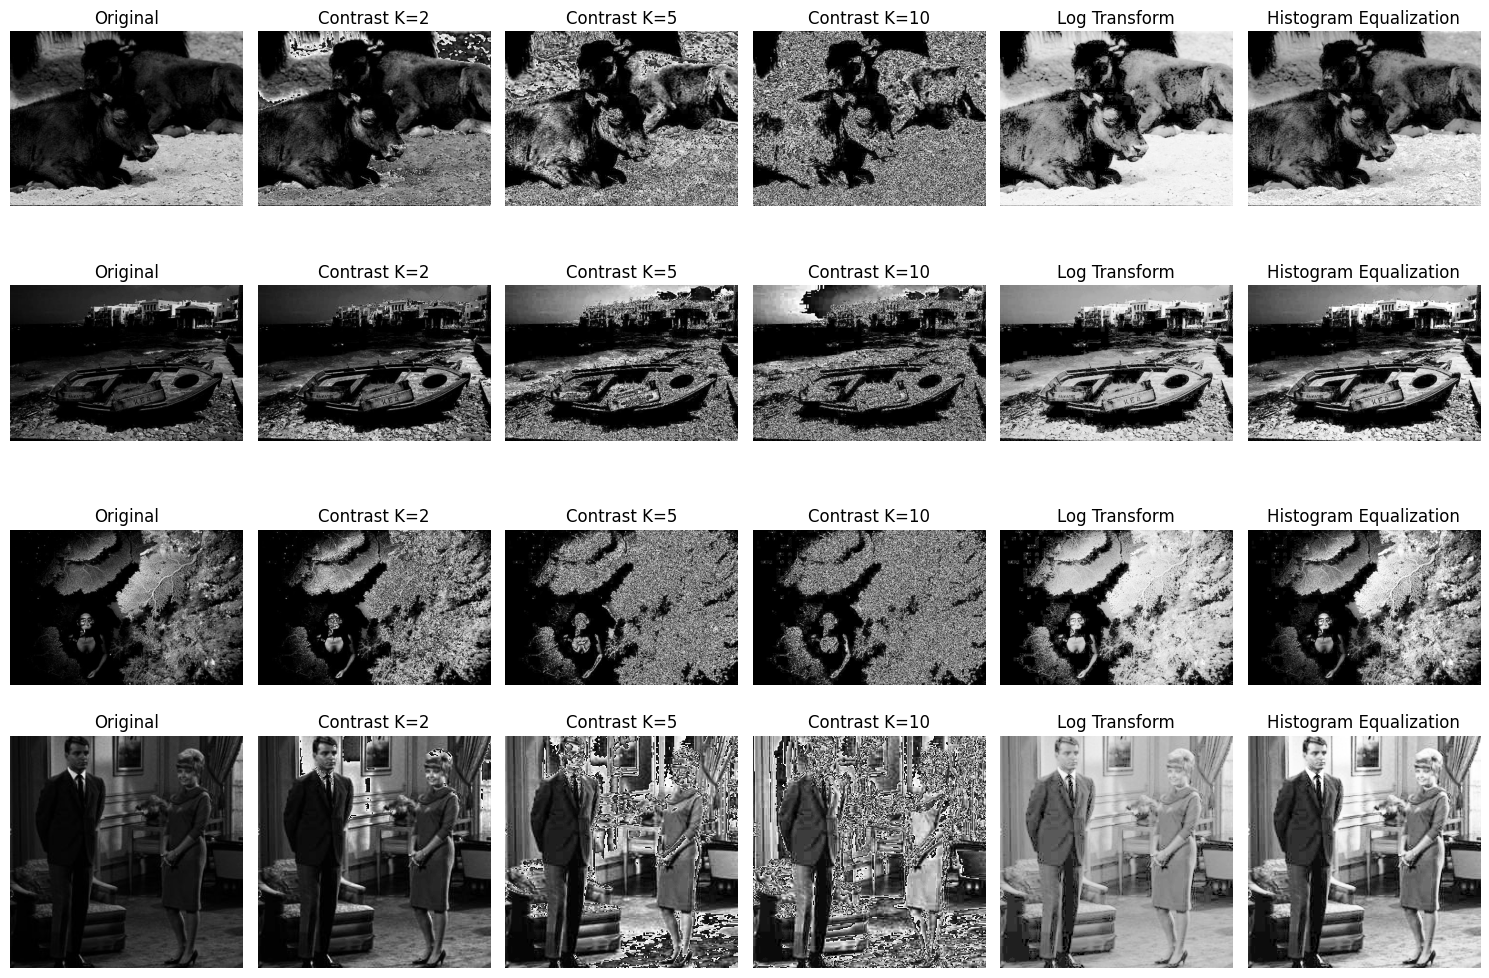

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Specify the paths to the 4 images you want to process
image_paths = [
    "/content/sample_data/cow.jpg",
    "/content/sample_data/boat.jpg",
    "/content/sample_data/drive.jpg",
    "/content/sample_data/couple.jpg"
]

# images from the specified paths in grayscale
images = [np.array(Image.open(path).convert("L")) for path in image_paths]

# contrast increment
def contrast_increment(image, K):
    return np.clip(K * image, 0, 255).astype(np.uint8)

# logarithmic transform
def log_transform(image):
    c = 255 / np.log(1 + np.max(image))  # Scaling factor
    return (c * np.log(1 + image)).astype(np.uint8)

# histogram equalization
def histogram_equalization(image):
    return cv2.equalizeHist(image)

# transformations to each image
transformed_images = []
for img in images:
    contrast_k2 = contrast_increment(img, K=2)
    contrast_k5 = contrast_increment(img, K=5)
    contrast_k10 = contrast_increment(img, K=10)

    log_img = log_transform(img)
    hist_eq_img = histogram_equalization(img)

    transformed_images.append({
        "original": img,
        "contrast_k2": contrast_k2,
        "contrast_k5": contrast_k5,
        "contrast_k10": contrast_k10,
        "log_transform": log_img,
        "histogram_equalization": hist_eq_img
    })

# Display results
fig, axes = plt.subplots(len(transformed_images), 6, figsize=(15, 10))
for i, transformations in enumerate(transformed_images):
    axes[i, 0].imshow(transformations["original"], cmap="gray")
    axes[i, 0].set_title("Original")

    axes[i, 1].imshow(transformations["contrast_k2"], cmap="gray")
    axes[i, 1].set_title("Contrast K=2")

    axes[i, 2].imshow(transformations["contrast_k5"], cmap="gray")
    axes[i, 2].set_title("Contrast K=5")

    axes[i, 3].imshow(transformations["contrast_k10"], cmap="gray")
    axes[i, 3].set_title("Contrast K=10")

    axes[i, 4].imshow(transformations["log_transform"], cmap="gray")
    axes[i, 4].set_title("Log Transform")

    axes[i, 5].imshow(transformations["histogram_equalization"], cmap="gray")
    axes[i, 5].set_title("Histogram Equalization")

# Hide axis labels for clarity
for ax in axes.flatten():
    ax.axis("off")

plt.tight_layout()
plt.show()
